<a href="https://colab.research.google.com/github/ryanrtrindade/an-lise_casasdeluxo/blob/C%C3%B3digos/Projeto_Pessoal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [105]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [106]:
df = pd.read_csv('/content/drive/MyDrive/PYTHON/Housing.csv')


In [107]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [108]:
#Ver os tipos de dados na tabela

print(df.dtypes)


price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [109]:
#Varios fatores podem influenciar o preço da casa, como tamanho, quantidade de comodos e outros fatores...
#Meu primeiro pensamento aqui é separar quantitativo de qualitativo para ter uma vizualização um pouco melhor

quanti = []
qualit = []

for i in df.dtypes.index:
    if df.dtypes[i] == 'object':
        qualit.append(i)
    else:
        quanti.append(i)

In [110]:
print(quanti)
print(qualit)


['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [111]:
df_quanti = df[quanti]
df_qualit = df[qualit]

In [112]:
df_quanti.describe()

#aq temos uma vizualição legal do valores numericos

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [113]:
print('Média dos preços:', df_quanti.price.mean().round(3))
print('Media da área:', df_quanti.area.mean().round(3))


#É interessante já termos a média de preço das casas e sua área



Média dos preços: 4766729.248
Media da área: 5150.541


In [114]:
#Agora vamos ver a relação do preço tem haver com a área ser mair ou não, pra isso vou pegar casas acima da média de preço a abaixo
media_area = df['area'].mean()

acima_da_media = df[df['area'] > media_area]
abaixo_da_media = df[df['area'] < media_area]

In [115]:
print('Preço: USD',acima_da_media['price'].mean().round(3))
print('Preço: USD',abaixo_da_media['price'].mean())

#conclusão, casas com área acima de média tem preço maior

Preço: USD 5922545.391
Preço: USD 3922800.0


In [116]:
#agora e os comodos?


print('Número de quartos:',acima_da_media['bedrooms'].mean().round(2))
print('Número de quartos:',abaixo_da_media['bedrooms'].mean().round(2))
print('Número de banheiros:',acima_da_media['bathrooms'].mean().round(2))
print('Número de banheiros:',abaixo_da_media['bathrooms'].mean().round(2))




Número de quartos: 3.11
Número de quartos: 2.86
Número de banheiros: 1.42
Número de banheiros: 1.19


In [117]:
#vamos dar uma olhada mais afundo nas qualitativas

for i in df_qualit.columns:
  if i == 'mainroad':
    pass
  else:
    print('---------------------')
    print('Variável:', i)
    print(df_qualit.groupby(i).mainroad.count())
    print('---------------------')

---------------------
Variável: guestroom
guestroom
no     448
yes     97
Name: mainroad, dtype: int64
---------------------
---------------------
Variável: basement
basement
no     354
yes    191
Name: mainroad, dtype: int64
---------------------
---------------------
Variável: hotwaterheating
hotwaterheating
no     520
yes     25
Name: mainroad, dtype: int64
---------------------
---------------------
Variável: airconditioning
airconditioning
no     373
yes    172
Name: mainroad, dtype: int64
---------------------
---------------------
Variável: prefarea
prefarea
no     417
yes    128
Name: mainroad, dtype: int64
---------------------
---------------------
Variável: furnishingstatus
furnishingstatus
furnished         140
semi-furnished    227
unfurnished       178
Name: mainroad, dtype: int64
---------------------


In [118]:
#Agora vamos verificar os nulos

#criar um data frame vazio
dadosnulos = pd.DataFrame()
#colocar todas colunas numa lista
dadosnulos['Variável'] = df.columns

In [119]:
dadosnulos

,Variável
0,price
1,area
2,bedrooms
3,bathrooms
4,stories
5,mainroad
6,guestroom
7,basement
8,hotwaterheating
9,airconditioning


In [120]:
dadosnulos['Quantidade'] = pd.Series()
dadosnulos['Porcentagem'] = pd.Series()

for i in dadosnulos.index :
  dadosnulos.loc[i, 'Quantidade'] = df[dadosnulos['Variável'][i]].isna().sum()
  dadosnulos[i, 'Porcentagem'] = (df[dadosnulos['Variável'][i]].isna().sum()/len(df)) * 100



In [121]:
dadosnulos
#Não temos dados nulos :)
#Mas caso tivesse, a trativa que eu faria seria simples: as colunas quantitativas eu iria preencher com a média, as qualitativas com moda usando random e choice
#caso fossem poucas linhas(ex:4) e baixa porcentagem eu iria remover

,Variável,Quantidade,Porcentagem,"(0, Porcentagem)","(1, Porcentagem)","(2, Porcentagem)","(3, Porcentagem)","(4, Porcentagem)","(5, Porcentagem)","(6, Porcentagem)","(7, Porcentagem)","(8, Porcentagem)","(9, Porcentagem)","(10, Porcentagem)","(11, Porcentagem)","(12, Porcentagem)"
0,price,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,area,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,bedrooms,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,bathrooms,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,stories,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,mainroad,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,guestroom,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,basement,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,hotwaterheating,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,airconditioning,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: >

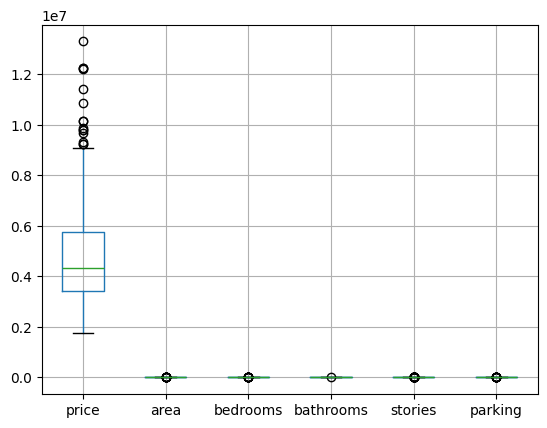

In [122]:
#Analisando outliers
df.boxplot()



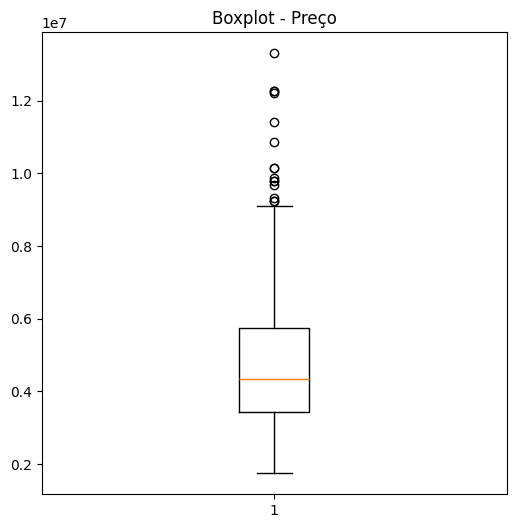

In [123]:
#vamos começar analisando price de maneira solitária

plt.figure(figsize = (6,6))
plt.boxplot(df['price'])
plt.title('Boxplot - Preço')
plt.show()

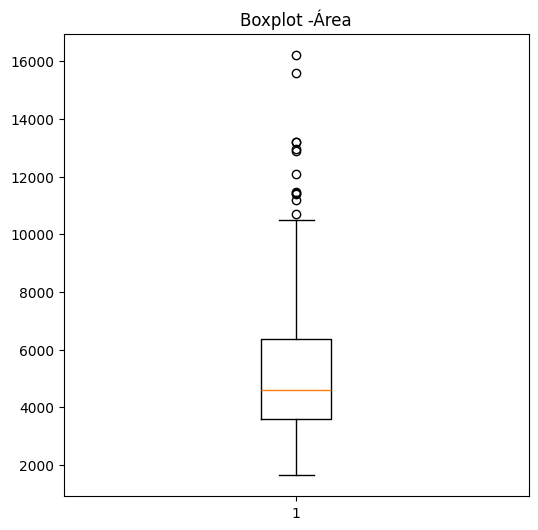

In [124]:
#agora da área

plt.figure(figsize = (6,6))
plt.boxplot(df['area'])
plt.title('Boxplot -Área')
plt.show()

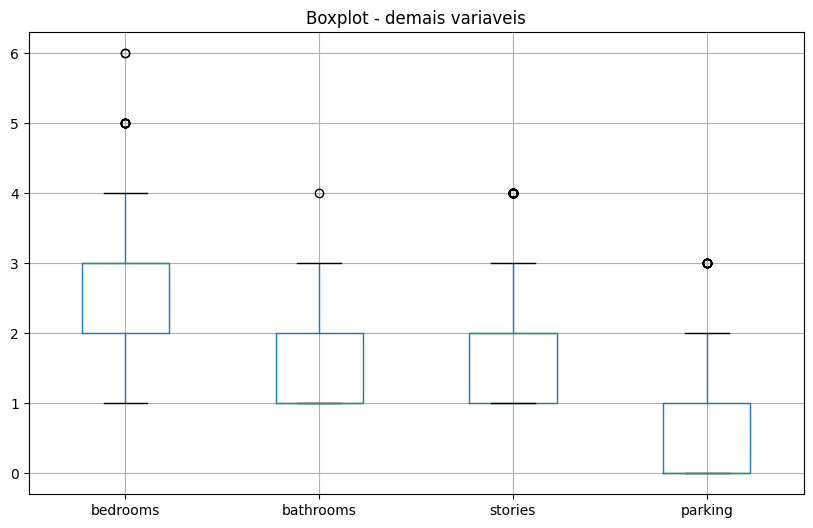

In [125]:
#Analisando os demais
variaveis = ['bedrooms', 'bathrooms', 'stories', 'parking']

df[variaveis].boxplot(figsize = (10,6))
plt.title('Boxplot - demais dados')
plt.show()

In [126]:
#Mas há um ponto: esse df é do mercado de luxo, então observando logicamente uma casa de 6 comodos mesmo sendo outlier extremo, pode ser compativel com o contexto e não sendo um erro

print(df['price'].mean().round(3))

#após ver a média de preços que está na casa dos milhões, vemos que esses outliers são totalmente válidos devido ao contexto da tabela



4766729.248


In [127]:
#Mas vamos pra area agora

Q1 = df['area'].quantile(0.25)
Q3 = df['area'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


area_outliers = df[(df['area'] < limite_inferior) | (df['area'] > limite_superior)]
area_outliers

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
10,9800000,13200,3,1,2,yes,no,yes,no,yes,2,yes,furnished
56,7343000,11440,4,1,2,yes,no,yes,no,no,1,yes,semi-furnished
64,7000000,11175,3,1,1,yes,no,yes,no,yes,1,yes,furnished
66,6930000,13200,2,1,1,yes,no,yes,yes,no,1,no,furnished
69,6790000,12090,4,2,2,yes,no,no,no,no,2,yes,furnished
125,5943000,15600,3,1,1,yes,no,no,no,yes,2,no,semi-furnished
129,5873000,11460,3,1,3,yes,no,no,no,no,2,yes,semi-furnished
186,5110000,11410,2,1,2,yes,no,no,no,no,0,yes,furnished
191,5040000,10700,3,1,2,yes,yes,yes,no,no,0,no,semi-furnished


In [128]:
#temos 12 linhas de 545 que são outliers, mas dentro do contexto é válido e os valores não alteram a correlação


#mas agora vamos para o preço também
preco_outliers = df[(df['price'] < limite_inferior) | (df['price'] > limite_superior)]
preco_outliers



,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [129]:
#aqui é a mesma lógica da área, 13 linhas de 545, e como o contexo é mercado de luxo, o valor de 13 milhões mesmo sendo muito acima da média de valor, ele é justificavel devido ao contexto




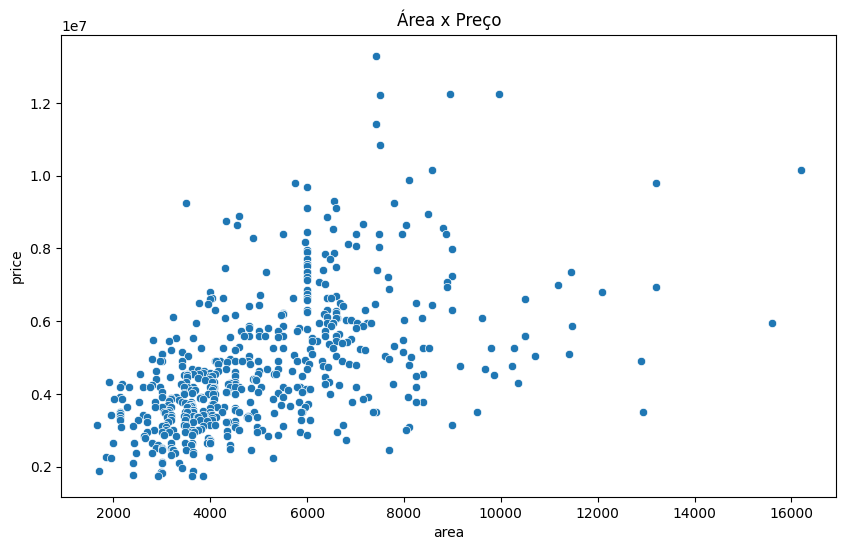

In [130]:
#Correlação de preço com área

plt.figure(figsize = (10,6))
sns.scatterplot( x = 'area', y = 'price', data= df)
plt.title('Área x Preço')
plt.show()

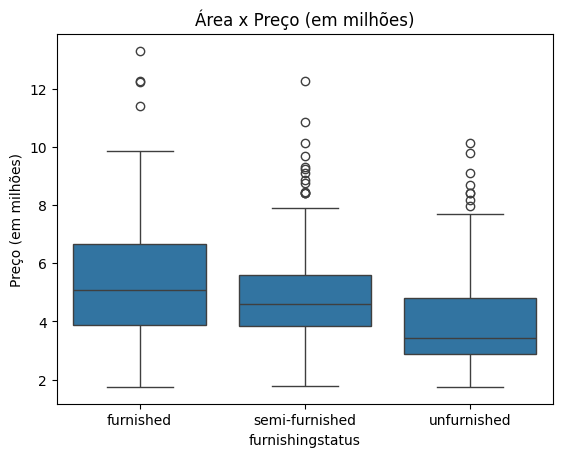

In [132]:
#Status de mobília do imóvel com preço

sns.boxplot(x='furnishingstatus', y=df['price']/1000000, data= df)
plt.ylabel('Preço (em milhões)')
plt.title('Área x Preço (em milhões)')
plt.show()

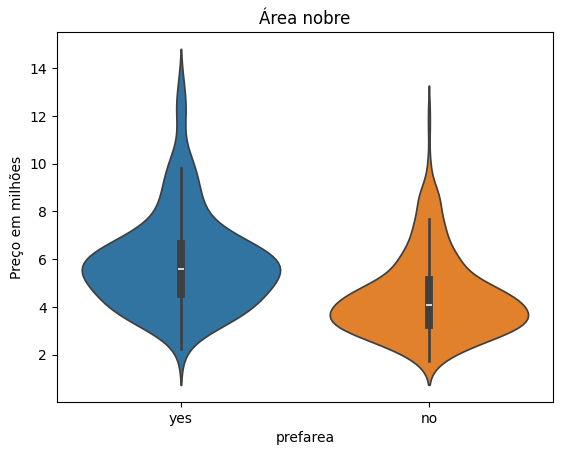

In [134]:
#Correlação entre área nibre e preço das casas

sns.violinplot(x ='prefarea', y=df['price']/1000000, data = df, hue = 'prefarea')
plt.ylabel('Preço em milhões')
plt.title('Área nobre')
plt.show()

In [135]:
#Aqui temos duas conclusões:
#1) Temos mais casas em áreas não preferências
#2) Casas em áreas preferências estão concentradas em valores mais altos

<Axes: >

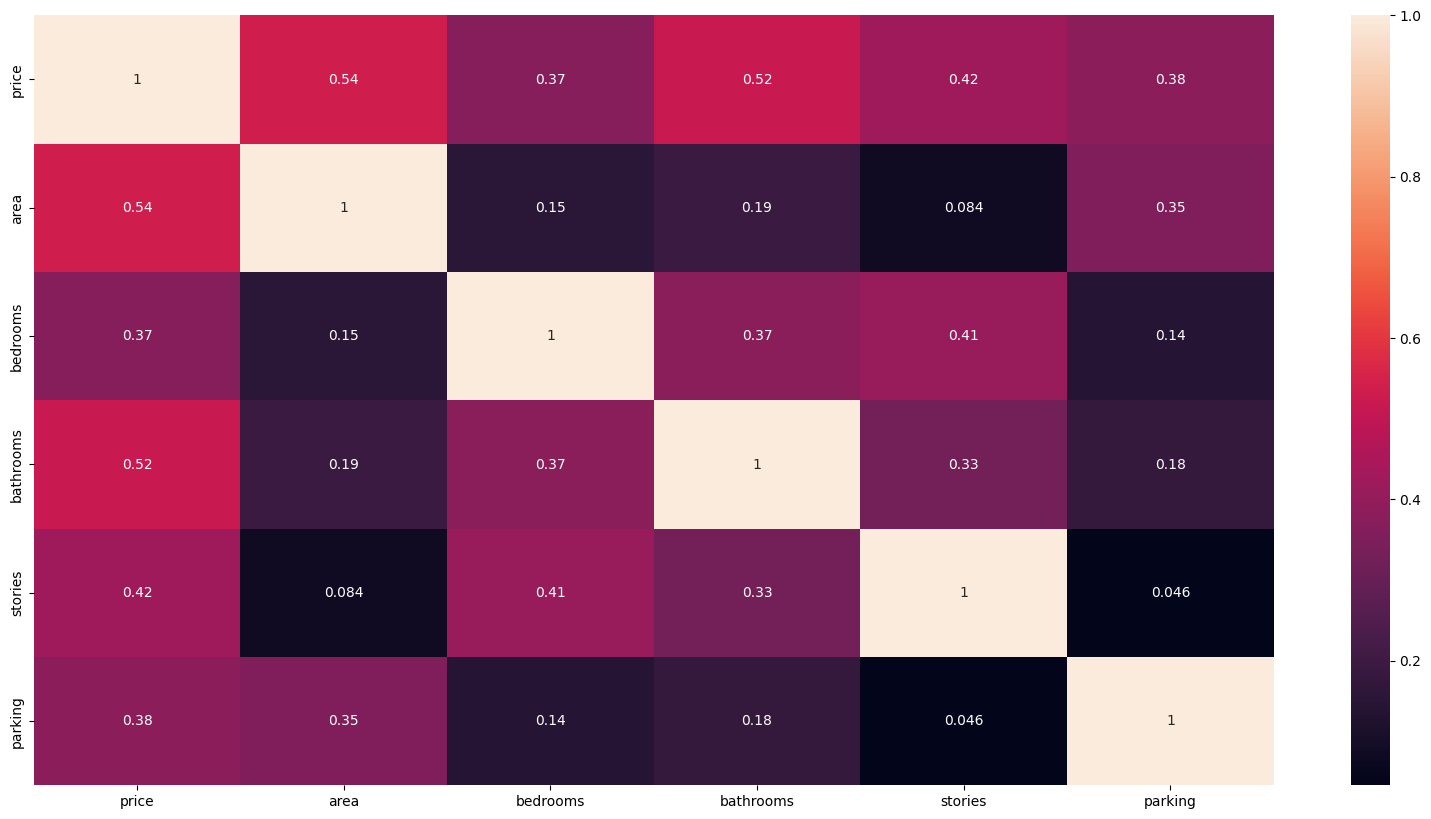

In [136]:
#Pra fechar, o heatmap vai entregar a correlação entre dados numéricos

plt.figure(figsize=(20, 10))
sns.heatmap(df.select_dtypes(include = 'number').corr(), annot = True)